# Exploratory Data Analysis of Seismic Signals (HDF5)

This notebook performs AED on the signals stored in `data/processed/signals.hdf5`.

## Objectives:
1. Load and inspect the HDF5 file structure
2. Examine metadata (intervals, labels, event properties)
3. Analyze signal characteristics (duration, sampling rate, etc.)
4. Visualize sample waveforms for events and non-events
5. Compare event vs non-event signal patterns

In [1]:
# Import required libraries
import sys
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from obspy import Trace, Stream

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

from config.config import PROCESSED_DATA_PATH

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load HDF5 file
hdf5_file = Path(PROCESSED_DATA_PATH) / "signals.hdf5"

# Alternative: Use absolute path if config path doesn't work
if not hdf5_file.exists():
    hdf5_file = Path("../data/processed/signals.hdf5")

if not hdf5_file.exists():
    print(f"✗ File not found: {hdf5_file}")
    print(f"  Tried: {Path(PROCESSED_DATA_PATH) / 'signals.hdf5'}")
    print(f"  Also tried: ../data/processed/signals.hdf5")
    print("  Please run scripts/get_signals.py first")
else:
    print(f"✓ HDF5 file found: {hdf5_file}")
    file_size_mb = hdf5_file.stat().st_size / (1024 * 1024)
    print(f"  File size: {file_size_mb:.2f} MB")
    
    # Open and explore file structure
    with h5py.File(hdf5_file, 'r') as hf:
        print(f"\n📁 HDF5 File Structure:")
        print(f"  Top-level groups: {list(hf.keys())}")
        
        # Metadata info
        if 'metadata' in hf:
            print(f"\n  Metadata datasets: {list(hf['metadata'].keys())}")
            n_intervals = len(hf['metadata']['id'])
            print(f"  Number of intervals: {n_intervals}")
        
        # Signals info
        if 'signals' in hf:
            signal_ids = list(hf['signals'].keys())
            print(f"\n  Number of stored signals: {len(signal_ids)}")
            print(f"  Sample signal IDs: {signal_ids[:5]}")

✓ HDF5 file found: ..\data\processed\signals.hdf5
  File size: 4.18 MB

📁 HDF5 File Structure:
  Top-level groups: ['metadata', 'signals']

  Metadata datasets: ['date', 'duration', 'end_time', 'id', 'label', 'lat', 'long', 'mag', 'start_time']
  Number of intervals: 342

  Number of stored signals: 329
  Sample signal IDs: ['non_event_1', 'non_event_10', 'non_event_100', 'non_event_102', 'non_event_103']


In [3]:
# Load metadata into DataFrame
with h5py.File(hdf5_file, 'r') as hf:
    metadata_dict = {}
    for key in hf['metadata'].keys():
        data = hf['metadata'][key][:]
        # Decode bytes to string if necessary
        if data.dtype.kind == 'S':
            data = np.array([d.decode('utf-8') if d else '' for d in data])
        metadata_dict[key] = data
    
    metadata_df = pd.DataFrame(metadata_dict)

# Convert datetime columns
for col in ['start_time', 'end_time', 'date']:
    if col in metadata_df.columns:
        metadata_df[col] = pd.to_datetime(metadata_df[col])

# Convert numeric columns
for col in ['lat', 'long', 'mag', 'label', 'duration']:
    if col in metadata_df.columns:
        metadata_df[col] = pd.to_numeric(metadata_df[col], errors='coerce')

print("📊 Metadata Summary:")
print(f"  Shape: {metadata_df.shape}")
print(f"\nColumns: {list(metadata_df.columns)}")
print(f"\nFirst few rows:")
display(metadata_df.head())

print(f"\n📈 Data types:")
print(metadata_df.dtypes)

📊 Metadata Summary:
  Shape: (342, 9)

Columns: ['date', 'duration', 'end_time', 'id', 'label', 'lat', 'long', 'mag', 'start_time']

First few rows:


,date,duration,end_time,id,label,lat,long,mag,start_time
0,2023-11-03 14:10:34.878641,78.111917,2023-11-03 14:11:13.934599,non_event_104,0,NaN,NaN,NaN,2023-11-03 14:09:55.822682
1,2023-11-05 15:48:11.173000,122.507039,2023-11-05 15:49:05.358940,query?eventid=11764934,1,-20.2143,-70.1323,3.3,2023-11-05 15:47:02.851901
2,2023-11-07 18:25:31.129000,49.636222,2023-11-07 18:26:00.767855,query?eventid=11765369,1,-20.7783,-69.1579,4.4,2023-11-07 18:25:11.131633
3,2023-11-10 08:38:37.934527,190.807366,2023-11-10 08:40:13.338210,non_event_48,0,NaN,NaN,NaN,2023-11-10 08:37:02.530844
4,2023-11-11 01:09:34.536411,104.104756,2023-11-11 01:10:26.588789,non_event_166,0,NaN,NaN,NaN,2023-11-11 01:08:42.484033



📈 Data types:
date          datetime64[ns]
duration             float64
end_time      datetime64[ns]
id                    object
label                  int64
lat                  float64
long                 float64
mag                  float64
start_time    datetime64[ns]
dtype: object


LABEL DISTRIBUTION

Event (1): 171
Non-event (0): 171
Total: 342


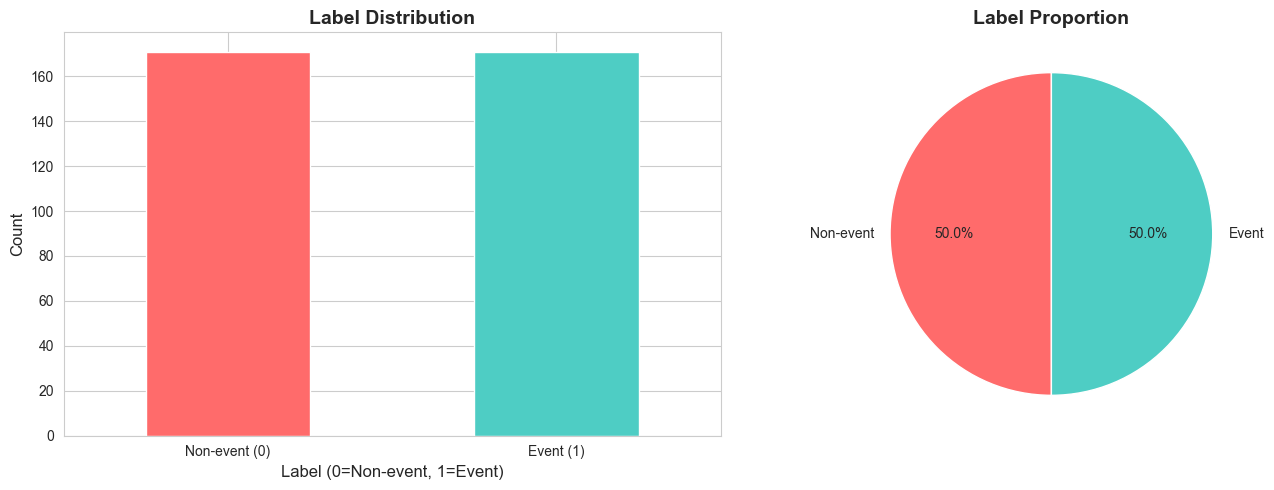


DURATION STATISTICS

Overall Duration Statistics:
count    342.000000
mean      97.204164
std       49.763490
min       -7.683582
25%       50.658408
50%       93.940378
75%      134.434879
max      204.061771
Name: duration, dtype: float64

Duration by Label:
       count       mean        std        min        25%        50%  \
label                                                                 
0      171.0  97.893375  49.309108  40.000000  45.087757  94.345243   
1      171.0  96.514953  50.349114  -7.683582  57.611800  93.535514   

              75%         max  
label                          
0      136.274803  201.451468  
1      134.097463  204.061771  

EVENT CHARACTERISTICS (Label=1)

Number of events: 171

Magnitude statistics:
count    171.000000
mean       4.321637
std        0.420294
min        2.900000
25%        4.100000
50%        4.300000
75%        4.500000
max        5.800000
Name: mag, dtype: float64

Location range:
  Latitude: -20.9612 to -18.3995
  Longitud

In [4]:
# Statistical Analysis of Metadata

print("=" * 70)
print("LABEL DISTRIBUTION")
print("=" * 70)
label_counts = metadata_df['label'].value_counts().sort_index()
print(f"\nEvent (1): {label_counts.get(1, 0)}")
print(f"Non-event (0): {label_counts.get(0, 0)}")
print(f"Total: {len(metadata_df)}")

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
label_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label (0=Non-event, 1=Event)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Non-event (0)', 'Event (1)'], rotation=0)

# Pie chart
axes[1].pie(label_counts, labels=['Non-event', 'Event'], autopct='%1.1f%%', 
            colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[1].set_title('Label Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("DURATION STATISTICS")
print("=" * 70)
if 'duration' in metadata_df.columns:
    print(f"\nOverall Duration Statistics:")
    print(metadata_df['duration'].describe())
    
    print(f"\nDuration by Label:")
    print(metadata_df.groupby('label')['duration'].describe())

print("\n" + "=" * 70)
print("EVENT CHARACTERISTICS (Label=1)")
print("=" * 70)
event_data = metadata_df[metadata_df['label'] == 1]
if len(event_data) > 0:
    print(f"\nNumber of events: {len(event_data)}")
    if 'mag' in event_data.columns:
        print(f"\nMagnitude statistics:")
        print(event_data['mag'].describe())
    if 'lat' in event_data.columns and 'long' in event_data.columns:
        print(f"\nLocation range:")
        print(f"  Latitude: {event_data['lat'].min():.4f} to {event_data['lat'].max():.4f}")
        print(f"  Longitude: {event_data['long'].min():.4f} to {event_data['long'].max():.4f}")

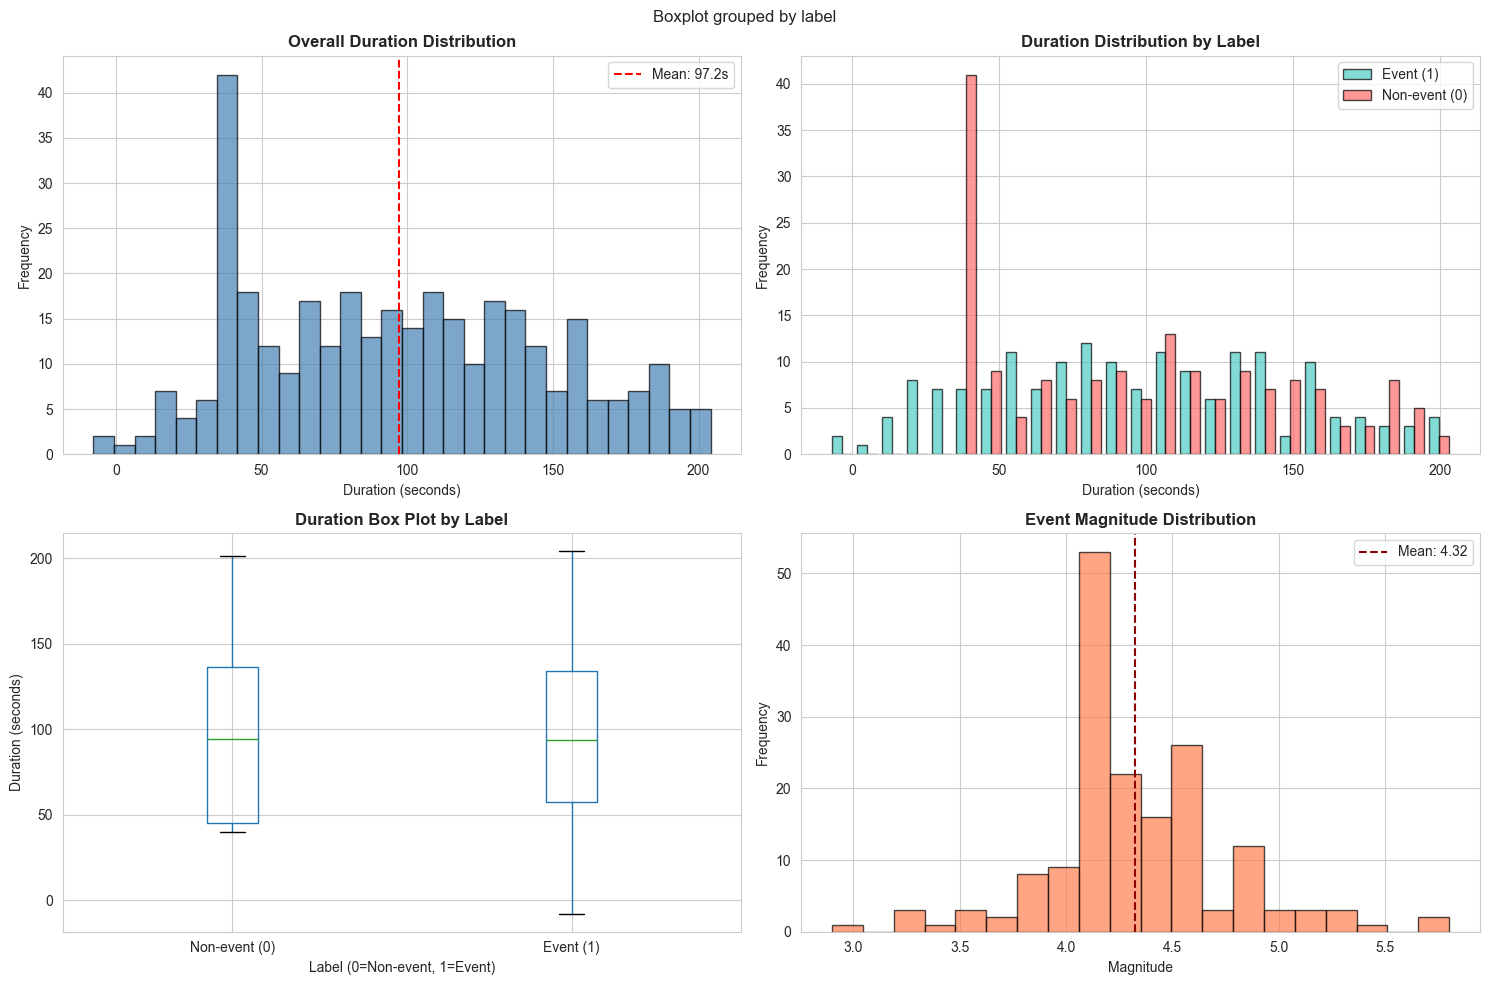

In [5]:
# Visualize Duration Distribution

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall duration histogram
if 'duration' in metadata_df.columns:
    axes[0, 0].hist(metadata_df['duration'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Overall Duration Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Duration (seconds)', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].axvline(metadata_df['duration'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {metadata_df["duration"].mean():.1f}s')
    axes[0, 0].legend()

    # Duration by label
    event_durations = metadata_df[metadata_df['label'] == 1]['duration']
    non_event_durations = metadata_df[metadata_df['label'] == 0]['duration']
    
    axes[0, 1].hist([event_durations, non_event_durations], bins=25, 
                    label=['Event (1)', 'Non-event (0)'], color=['#4ECDC4', '#FF6B6B'], 
                    edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Duration Distribution by Label', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Duration (seconds)', fontsize=10)
    axes[0, 1].set_ylabel('Frequency', fontsize=10)
    axes[0, 1].legend()

    # Box plot comparison
    metadata_df.boxplot(column='duration', by='label', ax=axes[1, 0])
    axes[1, 0].set_title('Duration Box Plot by Label', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Label (0=Non-event, 1=Event)', fontsize=10)
    axes[1, 0].set_ylabel('Duration (seconds)', fontsize=10)
    plt.sca(axes[1, 0])
    plt.xticks([1, 2], ['Non-event (0)', 'Event (1)'])

# Magnitude distribution for events
if 'mag' in metadata_df.columns:
    event_data = metadata_df[metadata_df['label'] == 1]
    axes[1, 1].hist(event_data['mag'].dropna(), bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Event Magnitude Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Magnitude', fontsize=10)
    axes[1, 1].set_ylabel('Frequency', fontsize=10)
    axes[1, 1].axvline(event_data['mag'].mean(), color='darkred', linestyle='--',
                       label=f'Mean: {event_data["mag"].mean():.2f}')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Analyze Signal Characteristics

print("=" * 70)
print("SIGNAL CHARACTERISTICS ANALYSIS")
print("=" * 70)

signal_info = []

with h5py.File(hdf5_file, 'r') as hf:
    if 'signals' in hf:
        signal_ids = list(hf['signals'].keys())
        
        print(f"\nAnalyzing {len(signal_ids)} signals...")
        
        for sig_id in signal_ids:
            sig_group = hf['signals'][sig_id]
            
            # Get label
            label = sig_group.attrs.get('label', None)
            num_traces = sig_group.attrs.get('num_traces', 0)
            
            # Analyze each trace
            for trace_name in sig_group.keys():
                trace_group = sig_group[trace_name]
                
                if 'data' in trace_group:
                    data = trace_group['data'][:]
                    sampling_rate = trace_group.attrs.get('sampling_rate', None)
                    channel = trace_group.attrs.get('channel', '').decode('utf-8') if isinstance(trace_group.attrs.get('channel'), bytes) else trace_group.attrs.get('channel', '')
                    
                    signal_info.append({
                        'interval_id': sig_id,
                        'label': label,
                        'trace': trace_name,
                        'num_points': len(data),
                        'sampling_rate': sampling_rate,
                        'duration_s': len(data) / sampling_rate if sampling_rate else None,
                        'mean_amplitude': np.mean(data),
                        'std_amplitude': np.std(data),
                        'min_amplitude': np.min(data),
                        'max_amplitude': np.max(data),
                        'channel': channel
                    })

signal_df = pd.DataFrame(signal_info)

print(f"\n✓ Analyzed {len(signal_df)} traces from {len(signal_ids)} intervals")
print(f"\nSignal DataFrame shape: {signal_df.shape}")
print(f"\nFirst few rows:")
display(signal_df.head(10))

print(f"\n📊 Signal Statistics by Label:")
print(signal_df.groupby('label')[['num_points', 'sampling_rate', 'duration_s', 'std_amplitude']].describe())

SIGNAL CHARACTERISTICS ANALYSIS

Analyzing 329 signals...

✓ Analyzed 329 traces from 329 intervals

Signal DataFrame shape: (329, 11)

First few rows:


,interval_id,label,trace,num_points,sampling_rate,duration_s,mean_amplitude,std_amplitude,min_amplitude,max_amplitude,channel
0,non_event_1,0,trace_0,7233,40.0,180.825,2.425966e+06,88.571441,2425706,2426257,BHZ
1,non_event_10,0,trace_0,5136,40.0,128.400,2.070233e+06,84.696606,2069962,2070483,BHZ
2,non_event_100,0,trace_0,1918,40.0,47.950,3.352167e+06,131.066300,3351771,3352614,BHZ
3,non_event_102,0,trace_0,2698,40.0,67.450,6.539126e+06,94.627310,6538827,6539488,BHZ
4,non_event_103,0,trace_0,5802,40.0,145.050,3.567131e+06,122.408152,3566821,3567417,BHZ
5,non_event_104,0,trace_0,3125,40.0,78.125,1.672416e+06,164.689261,1671968,1672874,BHZ
6,non_event_105,0,trace_0,5120,40.0,128.000,-7.868496e+05,60.698792,-787060,-786670,BHZ
7,non_event_108,0,trace_0,4230,40.0,105.750,4.582685e+06,91.938492,4582300,4582946,BHZ
8,non_event_109,0,trace_0,3669,40.0,91.725,1.289160e+06,115.683041,1288853,1289614,BHZ
9,non_event_11,0,trace_0,6253,40.0,156.325,3.481272e+06,180.938752,3480511,3481621,BHZ



📊 Signal Statistics by Label:
      num_points                                                            \
           count         mean          std     min     25%     50%     75%   
label                                                                        
0          162.0  3923.462963  1967.818615  1267.0  1822.5  3866.0  5487.5   
1          167.0  3927.491018  1986.662546    35.0  2371.5  3800.0  5391.0   

              sampling_rate        ... duration_s          std_amplitude  \
          max         count  mean  ...        75%      max         count   
label                              ...                                     
0      8059.0         162.0  40.0  ...   137.1875  201.475         162.0   
1      8162.0         167.0  40.0  ...   134.7750  204.050         167.0   

                                                                        \
               mean            std        min         25%          50%   
label                                            

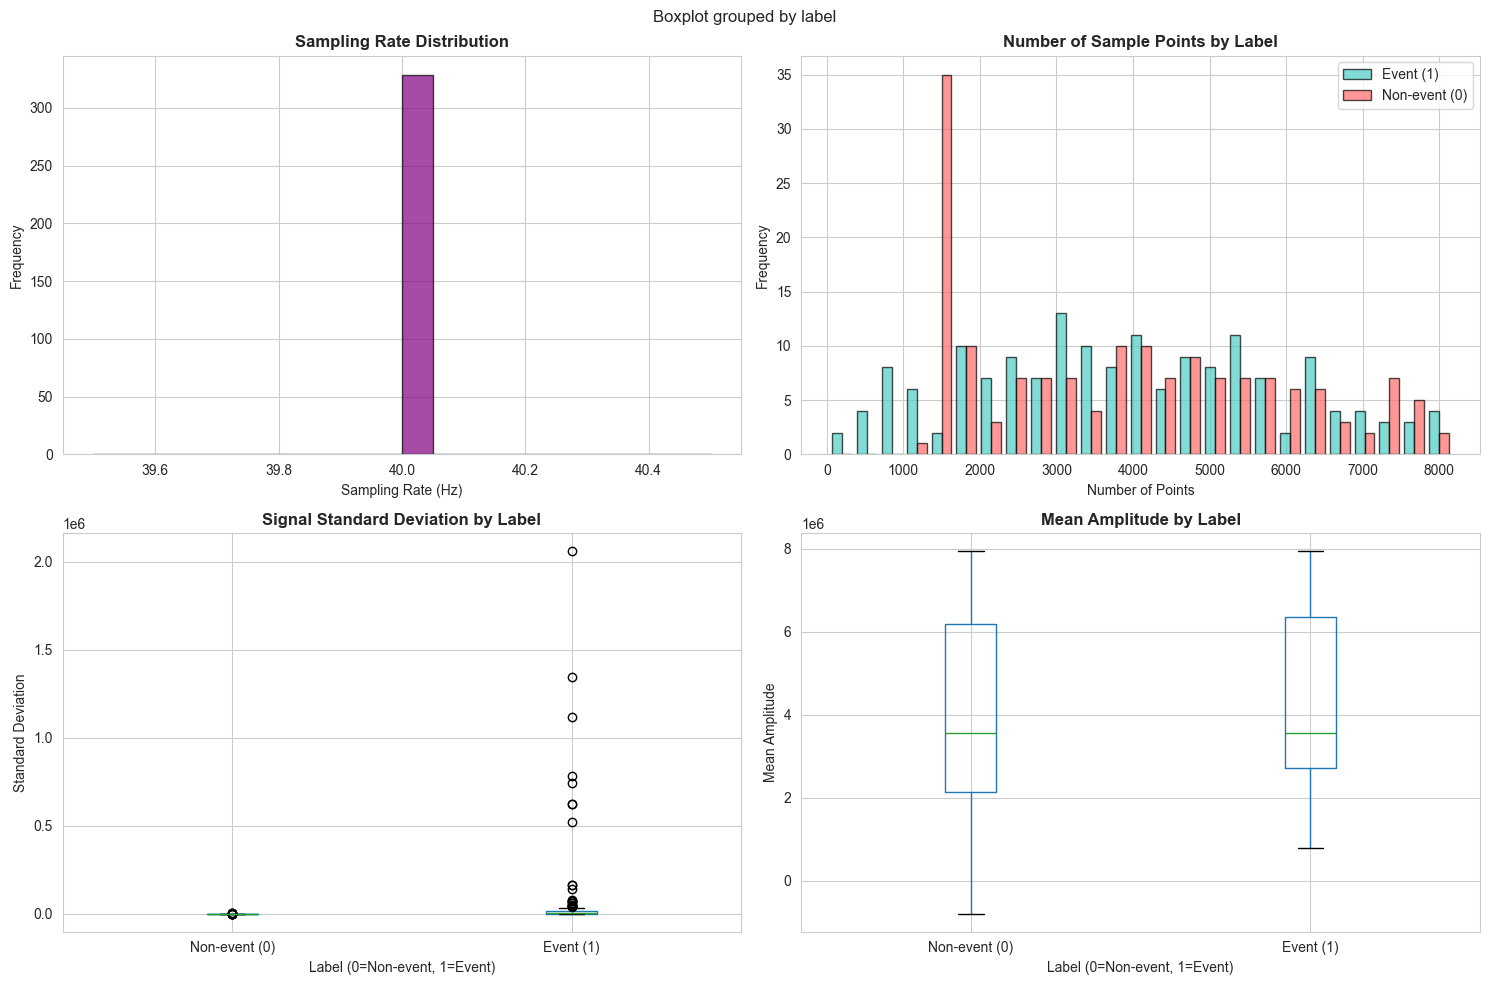


📈 Statistical Comparison (Event vs Non-event):

Standard Deviation:
       count          mean            std        min         25%          50%  \
label                                                                           
0      162.0    184.539502     251.061907  56.297317   98.245828   136.959305   
1      167.0  58692.210250  233806.155588  33.463260  230.335494  4052.143299   

                75%           max  
label                              
0        188.249697  2.878913e+03  
1      14721.143768  2.061872e+06  

Mean Amplitude:
       count          mean           std            min           25%  \
label                                                                   
0      162.0  4.077774e+06  2.386419e+06 -786849.627930  2.142112e+06   
1      167.0  4.272172e+06  2.204622e+06  800109.016892  2.716111e+06   

                50%           75%           max  
label                                            
0      3.566929e+06  6.190470e+06  7.946367e+06  
1 

In [7]:
# Visualize Signal Statistics

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sampling rate distribution
if 'sampling_rate' in signal_df.columns:
    axes[0, 0].hist(signal_df['sampling_rate'], bins=20, color='purple', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Sampling Rate Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Sampling Rate (Hz)', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)

# Number of points by label
event_signals = signal_df[signal_df['label'] == 1]
non_event_signals = signal_df[signal_df['label'] == 0]

axes[0, 1].hist([event_signals['num_points'], non_event_signals['num_points']], 
                bins=25, label=['Event (1)', 'Non-event (0)'], 
                color=['#4ECDC4', '#FF6B6B'], edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Number of Sample Points by Label', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Points', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].legend()

# Standard deviation comparison
signal_df.boxplot(column='std_amplitude', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Signal Standard Deviation by Label', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Label (0=Non-event, 1=Event)', fontsize=10)
axes[1, 0].set_ylabel('Standard Deviation', fontsize=10)
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Non-event (0)', 'Event (1)'])

# Mean amplitude comparison
signal_df.boxplot(column='mean_amplitude', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Mean Amplitude by Label', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Label (0=Non-event, 1=Event)', fontsize=10)
axes[1, 1].set_ylabel('Mean Amplitude', fontsize=10)
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Non-event (0)', 'Event (1)'])

plt.tight_layout()
plt.show()

print("\n📈 Statistical Comparison (Event vs Non-event):")
print("\nStandard Deviation:")
print(signal_df.groupby('label')['std_amplitude'].describe())
print("\nMean Amplitude:")
print(signal_df.groupby('label')['mean_amplitude'].describe())

## Waveform Visualization

Let's visualize sample waveforms for both event and non-event intervals to observe their patterns.

In [8]:
# Function to load and plot waveforms

def plot_waveform(hf, interval_id, label_name='Unknown'):
    """Plot waveform for a given interval."""
    if interval_id not in hf['signals']:
        print(f"Interval {interval_id} not found in signals")
        return
    
    sig_group = hf['signals'][interval_id]
    traces = list(sig_group.keys())
    
    fig, axes = plt.subplots(len(traces), 1, figsize=(14, 4*len(traces)))
    if len(traces) == 1:
        axes = [axes]
    
    for idx, trace_name in enumerate(traces):
        trace_group = sig_group[trace_name]
        data = trace_group['data'][:]
        sampling_rate = trace_group.attrs.get('sampling_rate', 1)
        channel = trace_group.attrs.get('channel', b'').decode('utf-8') if isinstance(trace_group.attrs.get('channel'), bytes) else trace_group.attrs.get('channel', '')
        
        # Create time axis
        time = np.arange(len(data)) / sampling_rate
        
        # Plot
        axes[idx].plot(time, data, linewidth=0.5, color='darkblue')
        axes[idx].set_title(f'{label_name} - Interval: {interval_id} - {trace_name} - Channel: {channel}', 
                           fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Time (seconds)', fontsize=10)
        axes[idx].set_ylabel('Amplitude', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f'Mean: {np.mean(data):.2e}\nStd: {np.std(data):.2e}\nMin: {np.min(data):.2e}\nMax: {np.max(data):.2e}'
        axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes, 
                      fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

print("✓ Waveform plotting function defined")

✓ Waveform plotting function defined


SAMPLE EVENT WAVEFORMS (Label = 1)

Total event intervals: 167
Plotting first 3 events...



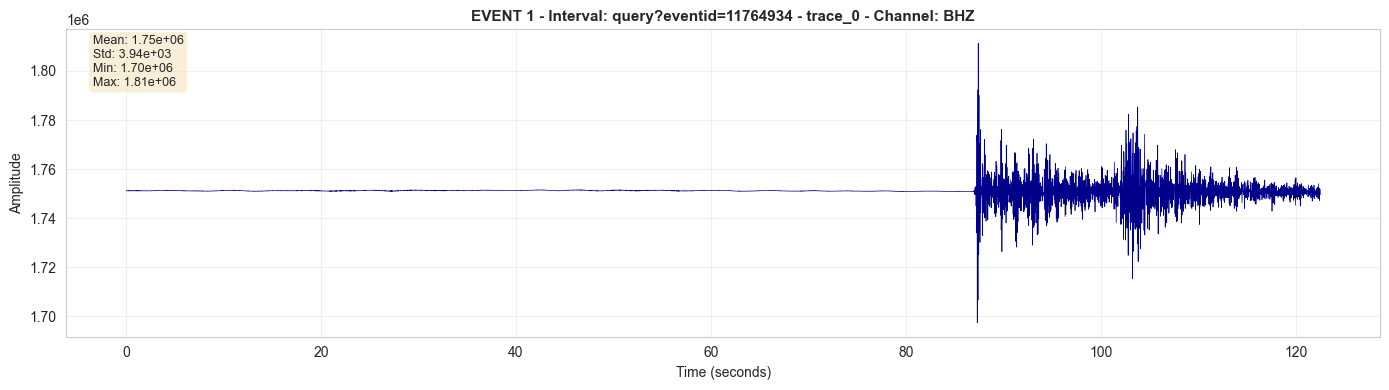

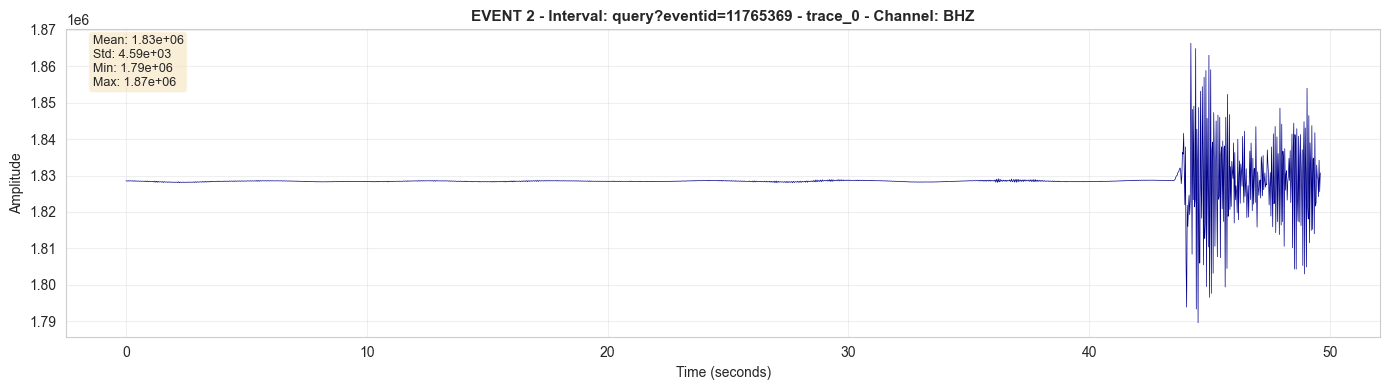

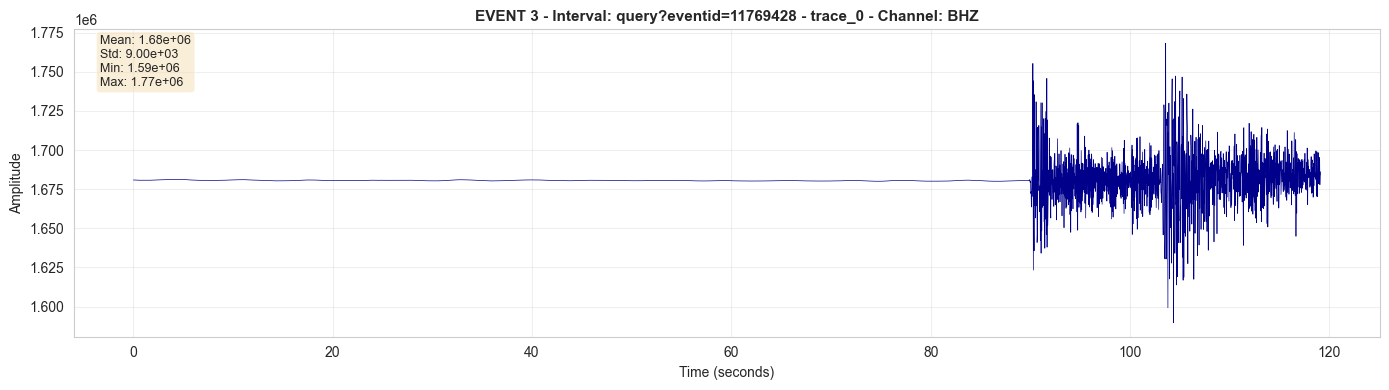

In [9]:
# Plot sample EVENT waveforms

print("=" * 70)
print("SAMPLE EVENT WAVEFORMS (Label = 1)")
print("=" * 70)

with h5py.File(hdf5_file, 'r') as hf:
    # Get event intervals
    event_intervals = []
    for sig_id in hf['signals'].keys():
        label = hf['signals'][sig_id].attrs.get('label', None)
        if label == 1:
            event_intervals.append(sig_id)
    
    print(f"\nTotal event intervals: {len(event_intervals)}")
    
    # Plot first 3 events
    num_to_plot = min(3, len(event_intervals))
    print(f"Plotting first {num_to_plot} events...\n")
    
    for i in range(num_to_plot):
        interval_id = event_intervals[i]
        plot_waveform(hf, interval_id, label_name=f'EVENT {i+1}')

SAMPLE NON-EVENT WAVEFORMS (Label = 0)

Total non-event intervals: 162
Plotting first 3 non-events...



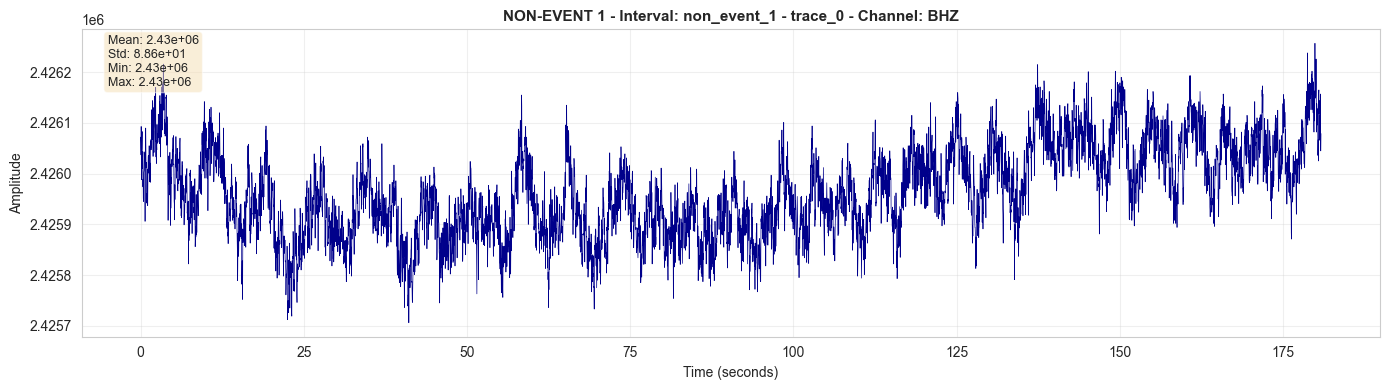

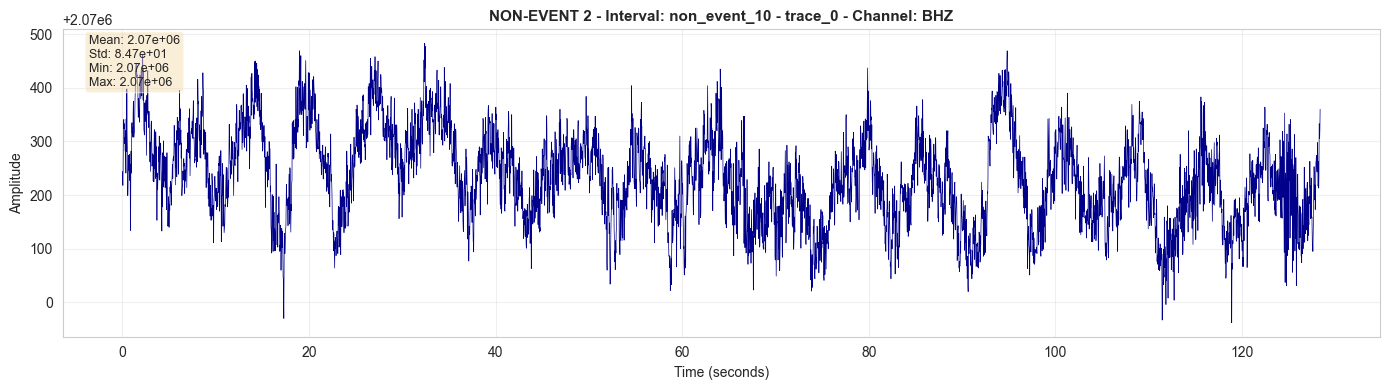

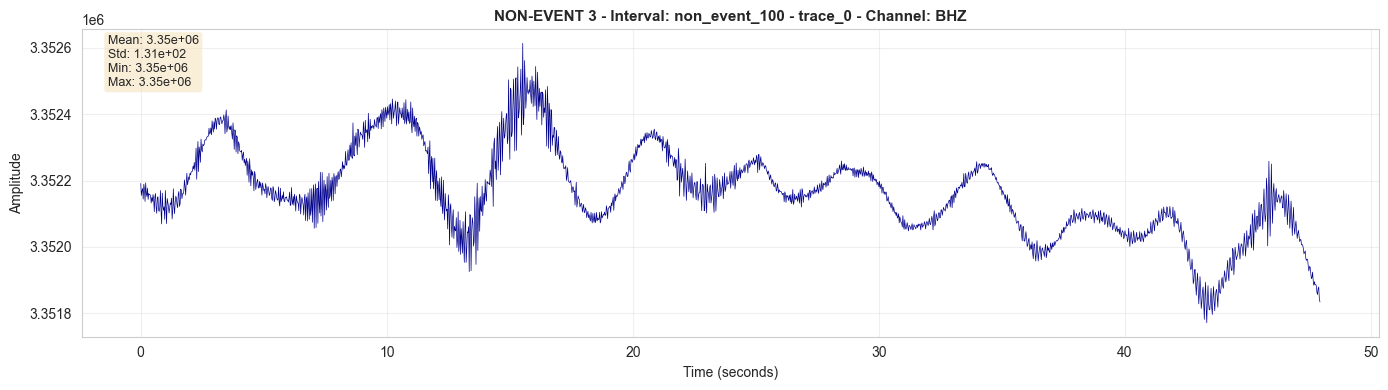

In [10]:
# Plot sample NON-EVENT waveforms

print("=" * 70)
print("SAMPLE NON-EVENT WAVEFORMS (Label = 0)")
print("=" * 70)

with h5py.File(hdf5_file, 'r') as hf:
    # Get non-event intervals
    non_event_intervals = []
    for sig_id in hf['signals'].keys():
        label = hf['signals'][sig_id].attrs.get('label', None)
        if label == 0:
            non_event_intervals.append(sig_id)
    
    print(f"\nTotal non-event intervals: {len(non_event_intervals)}")
    
    # Plot first 3 non-events
    num_to_plot = min(3, len(non_event_intervals))
    print(f"Plotting first {num_to_plot} non-events...\n")
    
    for i in range(num_to_plot):
        interval_id = non_event_intervals[i]
        plot_waveform(hf, interval_id, label_name=f'NON-EVENT {i+1}')

## Temporal Analysis

Analyze the distribution of events and non-events over time.

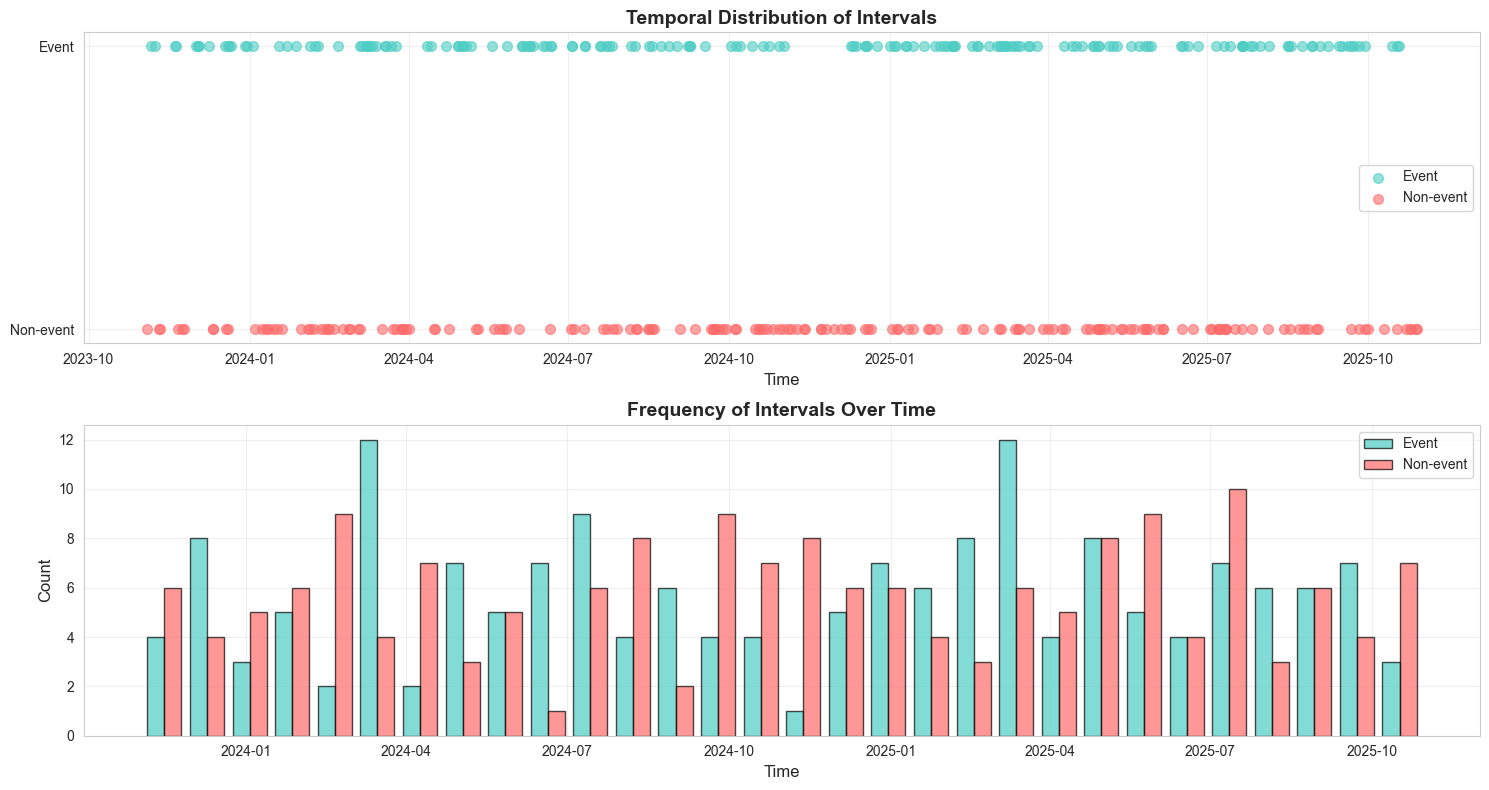

📅 Temporal Statistics:

Time range: 2023-11-03 14:09:55.822682 to 2025-10-28 12:22:13.563653
Total span: 724 days


In [11]:
# Temporal distribution of intervals

if 'start_time' in metadata_df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(15, 8))
    
    # Timeline of all intervals
    event_data = metadata_df[metadata_df['label'] == 1].sort_values('start_time')
    non_event_data = metadata_df[metadata_df['label'] == 0].sort_values('start_time')
    
    axes[0].scatter(event_data['start_time'], [1]*len(event_data), 
                   color='#4ECDC4', alpha=0.6, s=50, label='Event')
    axes[0].scatter(non_event_data['start_time'], [0]*len(non_event_data), 
                   color='#FF6B6B', alpha=0.6, s=50, label='Non-event')
    axes[0].set_title('Temporal Distribution of Intervals', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Time', fontsize=12)
    axes[0].set_yticks([0, 1])
    axes[0].set_yticklabels(['Non-event', 'Event'])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of events over time
    axes[1].hist([event_data['start_time'], non_event_data['start_time']], 
                bins=30, label=['Event', 'Non-event'], 
                color=['#4ECDC4', '#FF6B6B'], alpha=0.7, edgecolor='black')
    axes[1].set_title('Frequency of Intervals Over Time', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Time', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("📅 Temporal Statistics:")
    print(f"\nTime range: {metadata_df['start_time'].min()} to {metadata_df['start_time'].max()}")
    print(f"Total span: {(metadata_df['start_time'].max() - metadata_df['start_time'].min()).days} days")

## Summary and Key Findings

This section summarizes the main observations from the AED.

In [12]:
# Generate summary report

print("=" * 70)
print("COMPREHENSIVE SUMMARY REPORT")
print("=" * 70)

print("\n📊 DATASET OVERVIEW:")
print(f"  Total intervals: {len(metadata_df)}")
print(f"  Event intervals (label=1): {len(metadata_df[metadata_df['label']==1])}")
print(f"  Non-event intervals (label=0): {len(metadata_df[metadata_df['label']==0])}")
print(f"  HDF5 file size: {file_size_mb:.2f} MB")

if 'duration' in metadata_df.columns:
    print("\n⏱️ DURATION CHARACTERISTICS:")
    print(f"  Overall range: {metadata_df['duration'].min():.1f}s - {metadata_df['duration'].max():.1f}s")
    print(f"  Overall mean: {metadata_df['duration'].mean():.1f}s ± {metadata_df['duration'].std():.1f}s")
    print(f"  Event mean duration: {metadata_df[metadata_df['label']==1]['duration'].mean():.1f}s")
    print(f"  Non-event mean duration: {metadata_df[metadata_df['label']==0]['duration'].mean():.1f}s")

if len(signal_df) > 0:
    print("\n📡 SIGNAL PROPERTIES:")
    print(f"  Total traces: {len(signal_df)}")
    print(f"  Sampling rate: {signal_df['sampling_rate'].mode()[0]:.1f} Hz")
    print(f"  Mean points per trace: {signal_df['num_points'].mean():.0f}")
    
    print("\n📈 AMPLITUDE CHARACTERISTICS:")
    print(f"  Event signals - Mean std: {signal_df[signal_df['label']==1]['std_amplitude'].mean():.2e}")
    print(f"  Non-event signals - Mean std: {signal_df[signal_df['label']==0]['std_amplitude'].mean():.2e}")

if 'mag' in metadata_df.columns:
    event_mags = metadata_df[metadata_df['label']==1]['mag'].dropna()
    if len(event_mags) > 0:
        print("\n🌍 EVENT MAGNITUDES:")
        print(f"  Range: {event_mags.min():.2f} - {event_mags.max():.2f}")
        print(f"  Mean: {event_mags.mean():.2f} ± {event_mags.std():.2f}")

if 'start_time' in metadata_df.columns:
    print("\n📅 TEMPORAL COVERAGE:")
    print(f"  Start: {metadata_df['start_time'].min()}")
    print(f"  End: {metadata_df['start_time'].max()}")
    time_span = (metadata_df['start_time'].max() - metadata_df['start_time'].min()).days
    print(f"  Total span: {time_span} days ({time_span/30:.1f} months)")

COMPREHENSIVE SUMMARY REPORT

📊 DATASET OVERVIEW:
  Total intervals: 342
  Event intervals (label=1): 171
  Non-event intervals (label=0): 171
  HDF5 file size: 4.18 MB

⏱️ DURATION CHARACTERISTICS:
  Overall range: -7.7s - 204.1s
  Overall mean: 97.2s ± 49.8s
  Event mean duration: 96.5s
  Non-event mean duration: 97.9s

📡 SIGNAL PROPERTIES:
  Total traces: 329
  Sampling rate: 40.0 Hz
  Mean points per trace: 3926

📈 AMPLITUDE CHARACTERISTICS:
  Event signals - Mean std: 5.87e+04
  Non-event signals - Mean std: 1.85e+02

🌍 EVENT MAGNITUDES:
  Range: 2.90 - 5.80
  Mean: 4.32 ± 0.42

📅 TEMPORAL COVERAGE:
  Start: 2023-11-03 14:09:55.822682
  End: 2025-10-28 12:22:13.563653
  Total span: 724 days (24.1 months)
